<a href="https://colab.research.google.com/github/dhruvibhudiya07/Machine-Learning-labs/blob/main/Day3_BiasVariance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.dummy import DummyRegressor

SIGMA = 0.3

f = lambda x: np.sin(2 * np.pi * x)

def make_data(n, rng, fun=f, sigma=SIGMA):
    x = rng.uniform(0, 1, n)
    return x.reshape(-1, 1), fun(x) + rng.normal(0, sigma, n)

def poly(d):
    return make_pipeline(
        PolynomialFeatures(d),
        LinearRegression()
    )

def mse(a, b):
    return float(np.mean((a - b) ** 2))

In [25]:
rng = np.random.default_rng(42)

degs = list(range(1, 13))

Xte, yte = make_data(
    1000,
    np.random.default_rng(7)
)

tr = np.zeros(len(degs))
te = np.zeros(len(degs))

R = 50

for r in range(R):
    X, y = make_data(30, rng)

    for i, d in enumerate(degs):
        model = poly(d).fit(X, y)

        tr[i] += mse(y, model.predict(X)) / R
        te[i] += mse(yte, model.predict(Xte)) / R

print("Noise floor =", SIGMA**2)

for d, train, test in zip(degs, tr, te):
    print(
        f"Degree {d:2d}: "
        f"Train MSE = {train:.3f}, "
        f"Test MSE = {test:.3f}"
    )

best_degree = degs[int(np.argmin(te))]

print("\nBest test degree:", best_degree)

Noise floor = 0.09
Degree  1: Train MSE = 0.257, Test MSE = 0.315
Degree  2: Train MSE = 0.240, Test MSE = 0.346
Degree  3: Train MSE = 0.082, Test MSE = 0.115
Degree  4: Train MSE = 0.079, Test MSE = 0.124
Degree  5: Train MSE = 0.074, Test MSE = 0.137
Degree  6: Train MSE = 0.070, Test MSE = 0.170
Degree  7: Train MSE = 0.067, Test MSE = 3.307
Degree  8: Train MSE = 0.064, Test MSE = 0.625
Degree  9: Train MSE = 0.061, Test MSE = 8.466
Degree 10: Train MSE = 0.058, Test MSE = 21.174
Degree 11: Train MSE = 0.055, Test MSE = 654.662
Degree 12: Train MSE = 0.052, Test MSE = 53634.898

Best test degree: 3


In [26]:
X, y = make_data(
    30,
    np.random.default_rng(42)
)

train_values = []
test_values = []

for d in (1, 3, 9):
    model = poly(d).fit(X, y)

    train_values.append(
        round(mse(y, model.predict(X)), 3)
    )

    test_values.append(
        round(mse(yte, model.predict(Xte)), 3)
    )

print("Degree 1/3/9 train:", train_values)
print("Degree 1/3/9 test:", test_values)

Degree 1/3/9 train: [0.206, 0.064, 0.044]
Degree 1/3/9 test: [0.291, 0.101, 0.113]


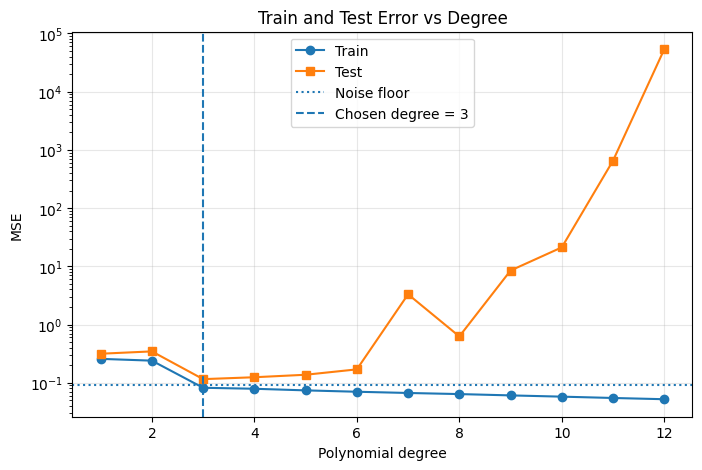

In [27]:
plt.figure(figsize=(8, 5))

plt.plot(
    degs,
    tr,
    "o-",
    label="Train"
)

plt.plot(
    degs,
    te,
    "s-",
    label="Test"
)

plt.axhline(
    SIGMA**2,
    linestyle=":",
    label="Noise floor"
)

plt.axvline(
    best_degree,
    linestyle="--",
    label=f"Chosen degree = {best_degree}"
)

plt.yscale("log")

plt.xlabel("Polynomial degree")
plt.ylabel("MSE")
plt.title("Train and Test Error vs Degree")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

In [28]:
grid = np.linspace(
    0.02,
    0.98,
    100
).reshape(-1, 1)

truth = f(grid.ravel())

def bias_var(d, n, reps=200, seed=0):

    rng = np.random.default_rng(seed)

    predictions = np.empty(
        (reps, len(grid))
    )

    for k in range(reps):

        X, y = make_data(n, rng)

        model = poly(d).fit(X, y)

        predictions[k] = model.predict(grid)

    mean_prediction = predictions.mean(0)

    bias_squared = np.mean(
        (mean_prediction - truth) ** 2
    )

    variance = predictions.var(0).mean()

    return float(bias_squared), float(variance), predictions

In [29]:
results = {}

for n in (30, 300):

    for d in (1, 3, 9):

        b, v, predictions = bias_var(d, n)

        results[(n, d)] = {
            "bias": b,
            "variance": v,
            "predictions": predictions
        }

        print(
            f"n={n}, Degree={d}, "
            f"Bias²={b:.4f}, "
            f"Variance={v:.4f}, "
            f"Bias²+Variance={b+v:.4f}"
        )

n=30, Degree=1, Bias²=0.1772, Variance=0.0220, Bias²+Variance=0.1991
n=30, Degree=3, Bias²=0.0035, Variance=0.0146, Bias²+Variance=0.0181
n=30, Degree=9, Bias²=0.0013, Variance=3.4785, Bias²+Variance=3.4797
n=300, Degree=1, Bias²=0.1771, Variance=0.0022, Bias²+Variance=0.1793
n=300, Degree=3, Bias²=0.0037, Variance=0.0012, Bias²+Variance=0.0049
n=300, Degree=9, Bias²=0.0000, Variance=0.0028, Bias²+Variance=0.0028


In [30]:
table1_data = []

for n in (30, 300):

    for d in (1, 3, 9):

        b = results[(n, d)]["bias"]
        v = results[(n, d)]["variance"]

        if n == 30 and d == 1:
            observation = "High bias"
        elif n == 30 and d == 3:
            observation = "Good balance"
        elif n == 30 and d == 9:
            observation = "Very high variance"
        elif n == 300 and d == 1:
            observation = "Bias remains high"
        elif n == 300 and d == 3:
            observation = "Low bias and variance"
        else:
            observation = "Variance greatly decreases"

        table1_data.append([
            n,
            d,
            round(b, 4),
            round(v, 4),
            round(b + v, 4),
            observation
        ])

table1 = pd.DataFrame(
    table1_data,
    columns=[
        "n",
        "Degree",
        "Bias squared",
        "Variance",
        "Bias squared + variance",
        "What I notice"
    ]
)

display(table1)

,n,Degree,Bias squared,Variance,Bias squared + variance,What I notice
0,30,1,0.1772,0.0220,0.1991,High bias
1,30,3,0.0035,0.0146,0.0181,Good balance
2,30,9,0.0013,3.4785,3.4797,Very high variance
3,300,1,0.1771,0.0022,0.1793,Bias remains high
4,300,3,0.0037,0.0012,0.0049,Low bias and variance
5,300,9,0.0000,0.0028,0.0028,Variance greatly decreases


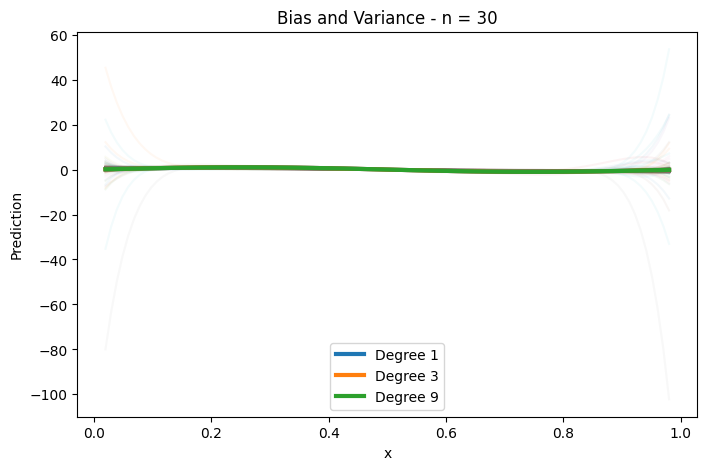

In [31]:
plt.figure(figsize=(8, 5))

for d in (1, 3, 9):

    predictions = results[
        (30, d)
    ]["predictions"]

    for k in range(200):
        plt.plot(
            grid.ravel(),
            predictions[k],
            alpha=0.05
        )

    plt.plot(
        grid.ravel(),
        truth,
        linewidth=3,
        label=f"Degree {d}"
    )

plt.xlabel("x")
plt.ylabel("Prediction")
plt.title("Bias and Variance - n = 30")
plt.legend()
plt.show()

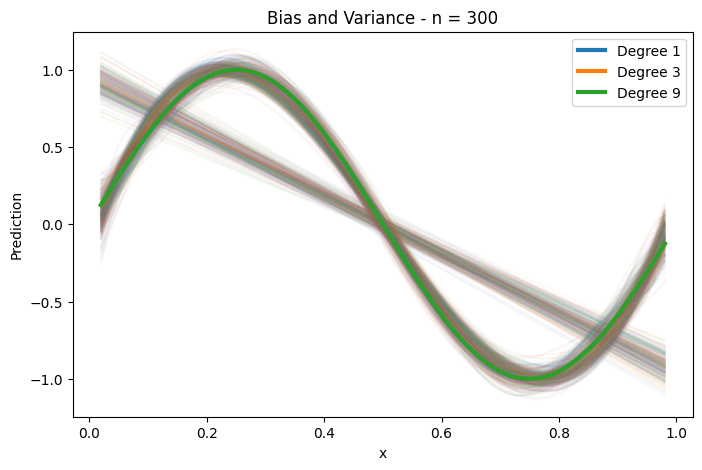

In [32]:
plt.figure(figsize=(8, 5))

for d in (1, 3, 9):

    predictions = results[
        (300, d)
    ]["predictions"]

    for k in range(200):
        plt.plot(
            grid.ravel(),
            predictions[k],
            alpha=0.05
        )

    plt.plot(
        grid.ravel(),
        truth,
        linewidth=3,
        label=f"Degree {d}"
    )

plt.xlabel("x")
plt.ylabel("Prediction")
plt.title("Bias and Variance - n = 300")
plt.legend()
plt.show()

In [33]:
fun = {
    "D1 linear": lambda x: 2 * x,
    "D2 curved": f,
    "D3 random": lambda x: np.zeros_like(x)
}

models = {
    "Linear reg": lambda: poly(1),
    "Degree-9 poly": lambda: poly(9),
    "kNN (k=5)": lambda: KNeighborsRegressor(5),
    "Mean": lambda: DummyRegressor()
}

In [34]:
rng = np.random.default_rng(11)

table = {}

for dn, fn in fun.items():

    acc = {
        model: 0.0
        for model in models
    }

    for r in range(100):

        X, y = make_data(
            30,
            rng,
            fun=fn
        )

        Xt, yt = make_data(
            500,
            rng,
            fun=fn
        )

        if dn == "D3 random":
            y = rng.normal(0, 1, 30)
            yt = rng.normal(0, 1, 500)

        for name, create_model in models.items():

            model = create_model()

            model.fit(X, y)

            prediction = model.predict(Xt)

            acc[name] += mse(
                yt,
                prediction
            ) / 100

    table[dn] = acc

    print(dn)

    for name, value in acc.items():
        print(name, round(value, 3))

    print(
        "Rank:",
        sorted(acc, key=acc.get)
    )
    print()

D1 linear
Linear reg 0.096
Degree-9 poly 48.244
kNN (k=5) 0.113
Mean 0.44
Rank: ['Linear reg', 'kNN (k=5)', 'Mean', 'Degree-9 poly']

D2 curved
Linear reg 0.302
Degree-9 poly 3.199
kNN (k=5) 0.136
Mean 0.606
Rank: ['kNN (k=5)', 'Linear reg', 'Mean', 'Degree-9 poly']

D3 random
Linear reg 1.056
Degree-9 poly 21.879
kNN (k=5) 1.184
Mean 1.023
Rank: ['Mean', 'Linear reg', 'kNN (k=5)', 'Degree-9 poly']



In [35]:
assumptions = {
    "Linear reg":
        "Assumes approximately linear relationship",

    "Degree-9 poly":
        "Assumes high-degree polynomial relationship",

    "kNN (k=5)":
        "Assumes nearby points have similar targets",

    "Mean":
        "Assumes overall mean is reasonable"
}

table2_data = []

for model in models:

    d1 = table["D1 linear"][model]
    d2 = table["D2 curved"][model]
    d3 = table["D3 random"][model]

    table2_data.append([
        model,
        round(d1, 3),
        round(d2, 3),
        round(d3, 3),
        assumptions[model]
    ])

table2 = pd.DataFrame(
    table2_data,
    columns=[
        "Predictor",
        "D1 y=2x",
        "D2 sine wave",
        "D3 pure noise",
        "The assumption it makes"
    ]
)

display(table2)

,Predictor,D1 y=2x,D2 sine wave,D3 pure noise,The assumption it makes
0,Linear reg,0.096,0.302,1.056,Assumes approximately linear relationship
1,Degree-9 poly,48.244,3.199,21.879,Assumes high-degree polynomial relationship
2,kNN (k=5),0.113,0.136,1.184,Assumes nearby points have similar targets
3,Mean,0.440,0.606,1.023,Assumes overall mean is reasonable


In [36]:
table1.to_csv(
    "Table1_Bias_Variance.csv",
    index=False
)

table2.to_csv(
    "Table2_No_Free_Lunch.csv",
    index=False
)

print("Tables saved successfully.")

Tables saved successfully.
